In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2, ResNet50V2
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2

from src import glob_vars

I0000 00:00:1781321547.297929   34197 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781321548.646429   34197 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Variables
ROOT_DIR = glob_vars['root_dir']
EPOCHS = glob_vars['epochs']
BATCH_SIZE = glob_vars['batch_size']
IMG_SIZE = glob_vars['input_size']
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)
ROTATION_DEGREE = glob_vars['rotation_range']

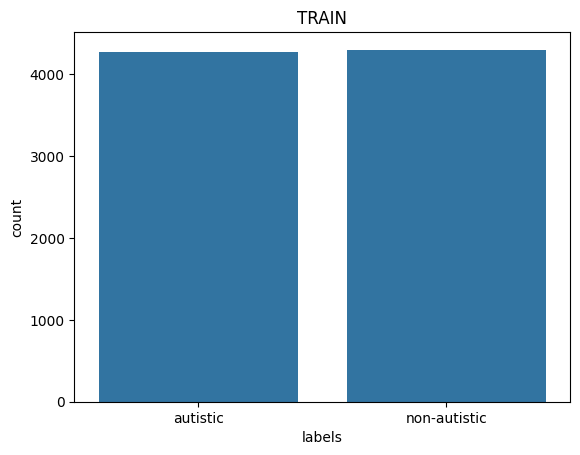

Train labels: 
labels
non-autistic    4300
autistic        4272
Name: count, dtype: int64


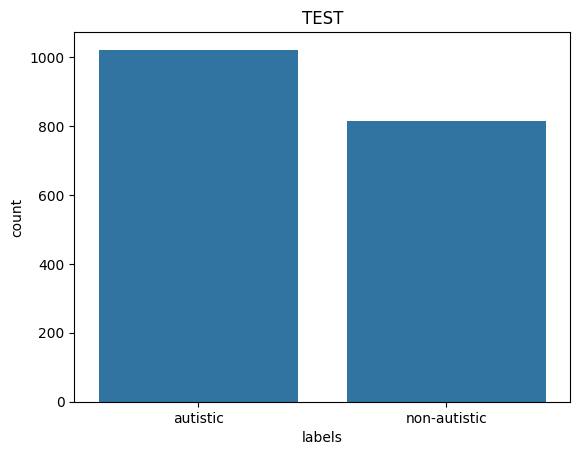

Test labels: 
labels
autistic        1021
non-autistic     815
Name: count, dtype: int64


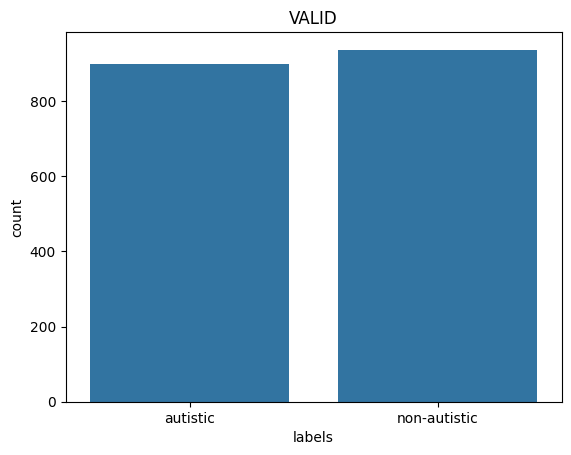

Valid labels: 
labels
non-autistic    937
autistic        899
Name: count, dtype: int64


In [3]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_train_70.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_test_15.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_valid_15.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
print(f"Train labels: ")
print(f"{train_df['labels'].value_counts()}")

sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
print(f"Test labels: ")
print(f"{test_df['labels'].value_counts()}")

sns.countplot(x='labels',data=valid_df)
plt.title('VALID')
plt.show()
print(f"Valid labels: ")
print(f"{valid_df['labels'].value_counts()}")

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=True
)

Found 8572 validated image filenames belonging to 2 classes.


In [5]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,       # Randomly rotates images by up to 20 degrees
    horizontal_flip=True,    # Flips images horizontally
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

Found 1836 validated image filenames belonging to 2 classes.


In [6]:
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuflle=True
)

Found 1836 validated image filenames belonging to 2 classes.


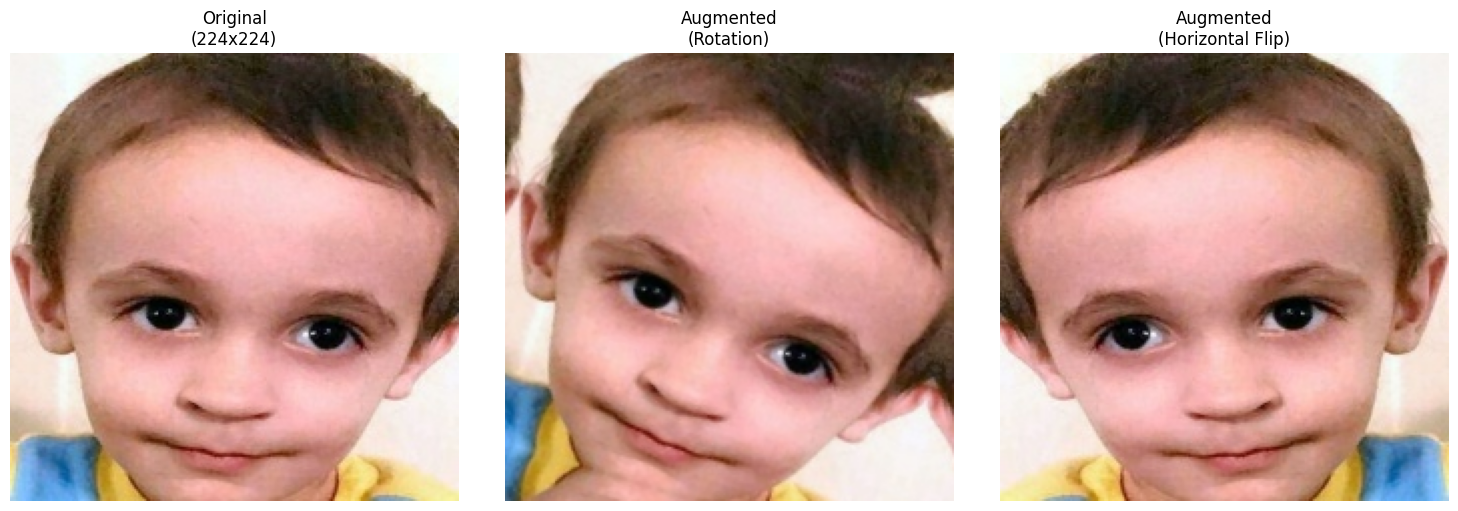

In [7]:
def visualisasi_preprocessing_aug(image_path):
    # 1. Load Original Image
    img_orig = cv2.imread(image_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    orig_shape = img_orig.shape
    
    # 2. Resize (Skenario Percobaan 1 & 3: 224x224)
    target_size = (224, 224)
    img_resized = cv2.resize(img_orig, target_size)
    
    # 3. Augmentasi (Horizontal Flip & Rotation)
    # Kita pake layer preprocessing Keras biar simpel
    data_augmentation_rotation = tf.keras.Sequential([
        # tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05), # Sekitar 72 derajat
    ])

    data_augmentation_flip = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        # tf.keras.layers.RandomRotation(0.2), # Sekitar 72 derajat
    ])
    
    # Tambah dimensi batch buat augmentasi (rotasi)
    img_aug_rotation = data_augmentation_rotation(tf.expand_dims(img_resized, 0))
    img_aug_rotation = tf.cast(img_aug_rotation[0], tf.uint8)

    # Tambah dimensi batch buat augmentasi (horizontal flip)
    img_aug_flip = data_augmentation_flip(tf.expand_dims(img_resized, 0))
    img_aug_flip = tf.cast(img_aug_flip[0], tf.uint8)

    # Plotting
    plt.figure(figsize=(15, 5))
    
    # # Tampilan Original
    # plt.subplot(1, 3, 1)
    # plt.imshow(img_orig)
    # plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    # plt.axis('off')
    
    # Tampilan Resized
    plt.subplot(1, 3, 1)
    plt.imshow(img_orig)
    plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    plt.axis('off')
    
    # Tampilan Augmented
    plt.subplot(1, 3, 2)
    plt.imshow(img_aug_rotation)
    plt.title("Augmented\n(Rotation)")
    plt.axis('off')

    # Tampilan Augmented
    plt.subplot(1, 3, 3)
    plt.imshow(img_aug_flip)
    plt.title("Augmented\n(Horizontal Flip)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_preprocessing_aug("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

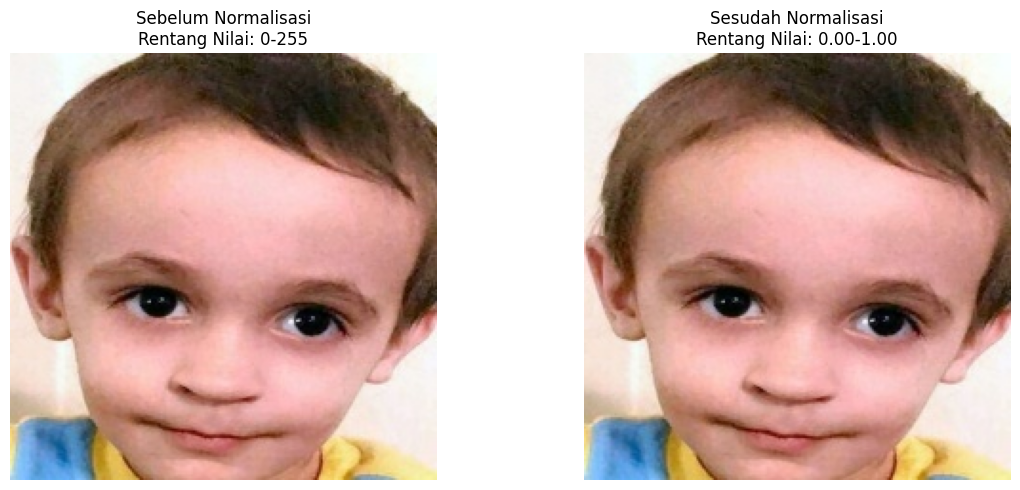

In [8]:
def visualisasi_normalisasi(img_path):
    # 1. Load Original (0-255)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    
    # 2. Normalisasi (Contoh: Scaling ke [0, 1])
    # Di Deep Learning, ini ngebantu konvergensi model lebih cepet
    img_normalized = img_array / 255.0 
    
    # 3. Plotting perbandingan
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Sebelum Normalisasi
    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title(f"Sebelum Normalisasi\nRentang Nilai: {int(np.min(img_array))}-{int(np.max(img_array))}")
    ax[0].axis('off')
    
    # Sesudah Normalisasi
    ax[1].imshow(img_normalized)
    ax[1].set_title(f"Sesudah Normalisasi\nRentang Nilai: {np.min(img_normalized):.2f}-{np.max(img_normalized):.2f}")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_normalisasi("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

In [9]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(1, activation="sigmoid")(combined)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipykernel_34197/1861757166.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer_2[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,704,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        513 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,527,745 (105.01 MB)

 Trainable params: 1,704,961 (6.50 MB)

 Non-trainable params: 25,822,784 (98.51 MB)

In [10]:
# === CALLBACKS ===
checkpoint = ModelCheckpoint("asr_s3.keras", monitor="val_accuracy", save_best_only=True)
earlystop = EarlyStopping(monitor="accuracy", patience=glob_vars['early_stopping_patience'], restore_best_weights=True)

In [11]:
# === TRAIN ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 94s 292ms/step - accuracy: 0.7474 - loss: 0.5299 - val_accuracy: 0.7386 - val_loss: 0.5183
Epoch 2/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 52s 194ms/step - accuracy: 0.7968 - loss: 0.4342 - val_accuracy: 0.8017 - val_loss: 0.4202
Epoch 3/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 50s 188ms/step - accuracy: 0.8156 - loss: 0.3980 - val_accuracy: 0.8350 - val_loss: 0.3716
Epoch 4/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 52s 194ms/step - accuracy: 0.8272 - loss: 0.3752 - val_accuracy: 0.8344 - val_loss: 0.3492
Epoch 5/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 52s 194ms/step - accuracy: 0.8427 - loss: 0.3475 - val_accuracy: 0.8573 - val_loss: 0.3234
Epoch 6/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 52s 194ms/step - accuracy: 0.8444 - loss: 0.3380 - val_accuracy: 0.8704 - val_loss: 0.3173
Epoch 7/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.8607 - loss: 0.3107 - val_accuracy: 0.8589 - val_loss: 0.3057
Epoch 8/50
268/268 ━━━━━━━━━━━━━━━━━━━━ 51s 189ms/step - accuracy: 0.8721 - loss: 0

In [12]:
# === EVALUATION ===
loss, acc = model.evaluate(test_gen)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")
# print(f"📉 Model Loss: {loss:.4f}")

error_rate = (1 - acc) * 100
print(f"❌ Error Rate: {error_rate:.2f}%")

58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.9581 - loss: 0.1265

🔥 Model Accuracy: 95.81%
❌ Error Rate: 4.19%


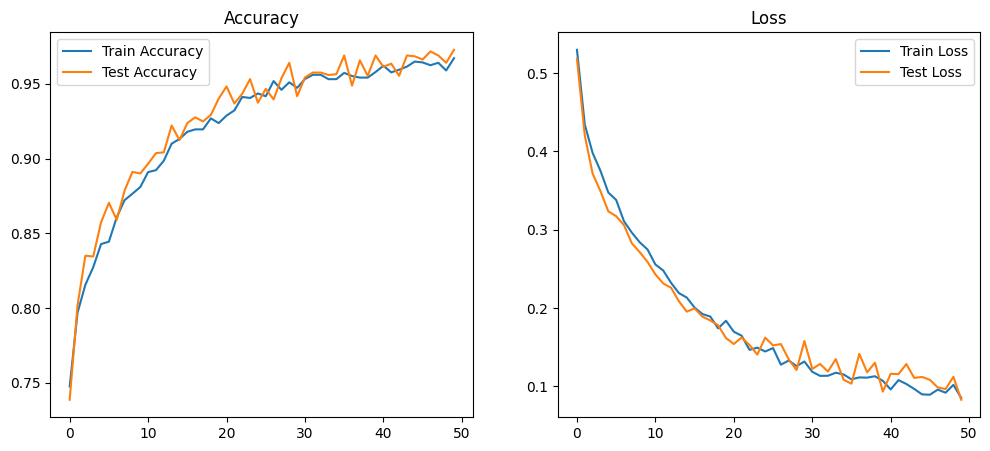

In [13]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 248ms/step
              precision    recall  f1-score   support

    autistic       0.95      0.98      0.97      1021
non-autistic       0.97      0.94      0.95       815

    accuracy                           0.96      1836
   macro avg       0.96      0.96      0.96      1836
weighted avg       0.96      0.96      0.96      1836



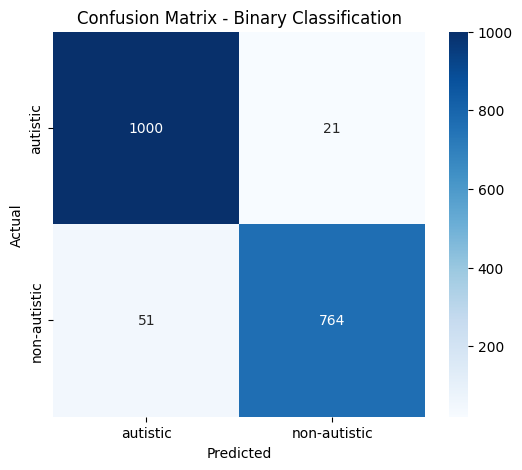

In [14]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen.classes  
class_labels = list(test_gen.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()